In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
# import dask
# import logging
# from dask.distributed import Client
from dask.diagnostics import ProgressBar

In [6]:
from glob import glob

In [7]:
# # client = Client(threads_per_worker = 1, memory_limit = 0, silence_log = logging.ERROR)
# client = Client()
# client

In [89]:
files_2t = glob('/g/data/rt52/era5/single-levels/reanalysis/2t/*/*.nc')
files_tp = glob('/g/data/rt52/era5/single-levels/reanalysis/tp/*/*.nc')

In [90]:
tas = xr.open_mfdataset(sorted(files_2t), parallel=True, combine='by_coords', chunks=dict(time=24))

KeyboardInterrupt: 

In [15]:
tp = xr.open_mfdataset(sorted(files_tp), parallel=True, combine='by_coords', chunks=dict(time=24))

In [ ]:
with ProgressBar():
    tmax_mel = tas.sel(latitude=19, longitude=72.8, method='nearest').coarsen(time=24).max('time').compute()
    tmin_mel = tas.sel(latitude=19, longitude=72.8, method='nearest').coarsen(time=24).min('time').compute()
    tp1hr_max = tp.sel(latitude=19, longitude=72.8, method='nearest').coarsen(time=24).max('time').compute()

[########################################] | 100% Completed | 151.87 s
[#########################               ] | 62% Completed | 46.88 ss

In [ ]:
# with ProgressBar():
#     tp3hr_max = tp.sel(latitude=-37.8, longitude=144.9, method='nearest').coarsen(time=3).sum('time').resample(time='1D').max('time').compute()

[########################################] | 100% Completed | 85.74 s


In [46]:
dtr = (tmax_mel.t2m - tmin_mel.t2m)
dtr

<xarray.DataArray 't2m' (time: 9010)>
array([11.058655 , 11.975006 , 16.912079 , ...,  2.9637146,  5.9556274,
        3.868988 ], dtype=float32)
Coordinates:
    longitude  float32 145.0
    latitude   float32 -37.75
  * time       (time) datetime64[ns] 2000-01-01T11:30:00 ... 2024-08-31T11:30:00

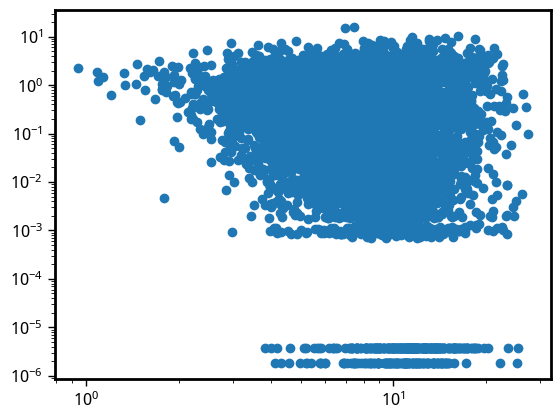

In [57]:
plt.scatter(dtr, tp1hr_max.tp*(10**3))
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')

In [81]:
dtr['time'] = tp1hr_max['time']

In [82]:
dtr_djf = dtr.where(dtr.time.dt.month.isin([12,1,2]), drop=True)
tp1hr_max_djf = tp1hr_max.where(dtr.time.dt.month.isin([12,1,2]), drop=True)

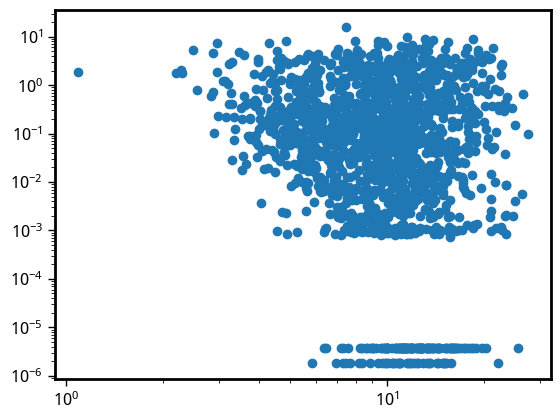

In [84]:
plt.scatter(dtr_djf, tp1hr_max_djf.tp*(10**3))
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')

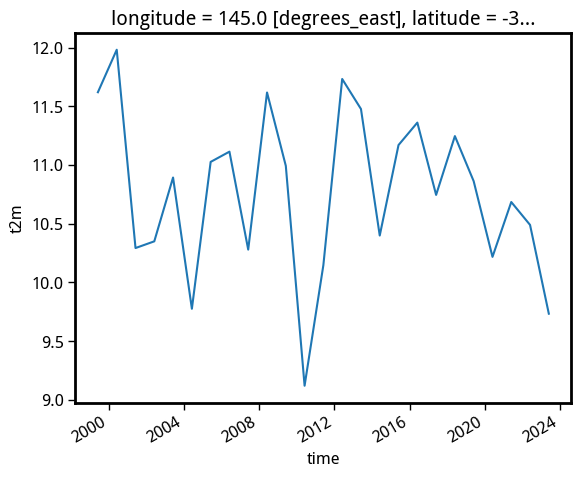

In [48]:
dtr['time'] = tp3hr_max['time']

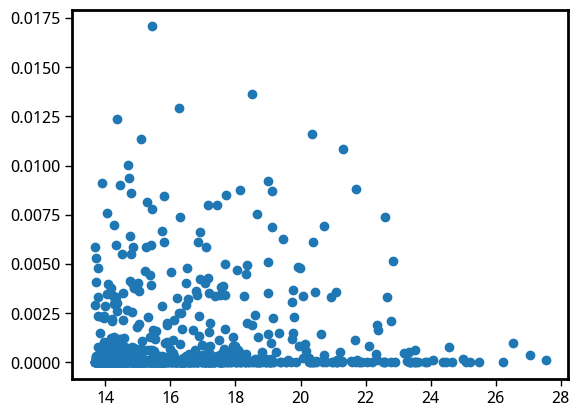

In [69]:
plt.scatter(dtr.where(dtr > dtr.quantile(0.90), drop=True), tp3hr_max.tp.where(dtr > dtr.quantile(0.90), drop=True))
# plt.gca().set_yscale('log')

In [26]:
test = tas.sel(latitude=-37.8, longitude=144.9, method='nearest').isel(time = slice(-96, -1)).compute()

In [70]:
test

<xarray.Dataset>
Dimensions:    (time: 95)
Coordinates:
    longitude  float32 145.0
    latitude   float32 -37.75
  * time       (time) datetime64[ns] 2024-08-28 ... 2024-08-31T22:00:00
Data variables:
    t2m        (time) float32 288.0 288.4 289.0 289.5 ... 286.7 286.6 287.2
Attributes:
    Conventions:  CF-1.6
    history:      2020-09-30 21:47:55 UTC+1000 by era5_replication_tools-1.2....
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis 2m_temperature 20000101-20000131

In [58]:
test1 = tp.sel(latitude=-37.8, longitude=144.9, method='nearest').isel(time = slice(-96, -1)).compute()

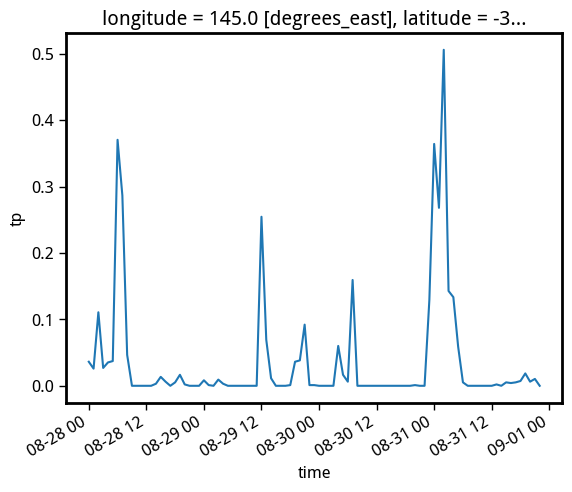

In [64]:
# test.t2m.plot()
(test1.tp*(10**3)).plot()

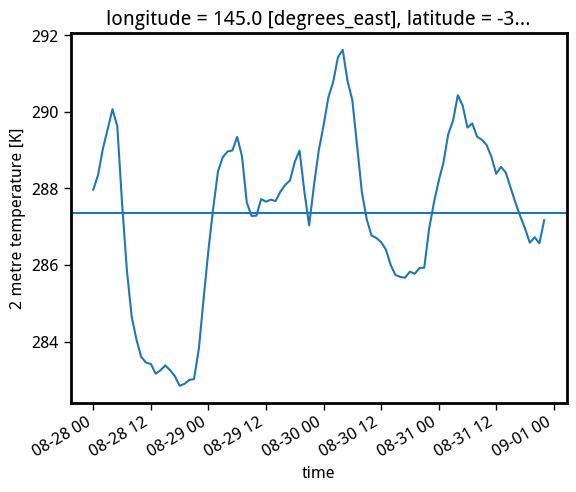

In [65]:
test.t2m.plot()
plt.axhline(test.t2m.mean())

In [10]:
with ProgressBar():
    tmax = tas.coarsen(time=24).max(keep_attrs=True).compute()

[                                        ] | 2% Completed | 181.39 ss


KeyboardInterrupt: 